# Spreadsheet to FAIRFluids Tutorial (CSV + XLSX)

This notebook shows the current recommended workflow for importing structured tabular data into FAIRFluids using `FluidIO`.

What is covered:
- Generate a parser-compatible template (`csv` or `xlsx`)
- Fill data in spreadsheet format (multiple properties per row)
- Import with global units at read-time
- Optional PubChem enrichment using `pubchemID i`
- Validate created documents/fluids/measurements


## 1) Imports and setup


In [37]:
from pathlib import Path

from fairfluids.core.fluid_io import FluidIO
from fairfluids.core.lib import FAIRFluidsDocument

fio = FluidIO()

print("Parsable properties:", fio.get_parsable_property_keywords())
print("Parsable parameters:", fio.get_parsable_parameter_keywords())

workflows_dir = Path("/home/sga/Code/FAIRFluids/Workflows")
workflows_dir.mkdir(parents=True, exist_ok=True)

Parsable properties: {'viscosity': 'VISCOSITY', 'density': 'DENSITY', 'conductivity': 'ELECTRICAL_CONDUCTIVITY', 'electrical_conductivity': 'ELECTRICAL_CONDUCTIVITY', 'thermal_conductivity': 'THERMAL_CONDUCTIVITY'}
Parsable parameters: {'temperature': 'TEMPERATURE', 'pressure': 'PRESSURE', 'mole_fraction': 'MOLE_FRACTION', 'molar_fraction': 'MOLE_FRACTION', 'time': 'TIME'}


## 2) Create a structured template (XLSX or CSV)


In [26]:
template_xlsx = workflows_dir / "cholinechloride_water.xlsx"

aio = fio.create_datasheet(
    output_path=str(template_xlsx),
    file_format="xlsx",              # or "csv"
    properties=["viscosity"],
    n_compounds=3,
    parameters=["time"],             # optional extra parameters
    n_rows=30,
)

print("Template written:", aio)
print("Fill the spreadsheet, then run the import cell below.")

Template written: /home/sga/Code/FAIRFluids/Workflows/cholinechloride_water.xlsx
Fill the spreadsheet, then run the import cell below.


In [38]:
# Use a filled spreadsheet path here
spreadsheet_path = workflows_dir / "cholinechloride_water.xlsx"  # or workflows_dir / "test.csv"

# Units can be supplied globally at read-time (unit columns in sheet are optional)
units = {
    "temperature": "K",
    "pressure": "bar",         # optional in data rows
    "viscosity": "cP",
    "density": "g/cm3",
    "conductivity": "mS/cm",
}
uncertainty_units = {
    "temperature": "K",
    "pressure": "bar",
    "viscosity": "cP",
    "density": "g/cm3",
    "conductivity": "mS/cm",
}

# Use data_from_spreadsheet (csv/xlsx) or data_from_csv (backward-compatible wrapper)
docs = fio.data_from_spreadsheet(
    spreadsheet_path=str(spreadsheet_path),
    fetch_from_pubchem=True,
    units=units,
    uncertainty_units=uncertainty_units,
)

print(f"Documents: {len(docs)}")
print(f"Fluids in first document: {len(docs[0].fluid) if docs else 0}")

docs

Found 1 unique compound combinations

Fetching compound information from PubChem for 2 unique compounds...

Fetched data for 2 compounds

  Added compound: Cholinechloride -> Choline Chloride (CID: 6209)
  Added compound: Water -> Water (CID: 962)
Documents: 1
Fluids in first document: 8


[FAIRFluidsDocument(version=Version(versionMajor=1, versionMinor=0), citation=None, compound=[Compound(compoundID='Choline Chloride', pubChemID=6209, commonName='Choline Chloride', SELFIE=None, name_IUPAC='2-hydroxyethyl(trimethyl)azanium chloride', standard_InChI='InChI=1S/C5H14NO.ClH/c1-6(2,3)4-5-7;/h7H,4-5H2,1-3H3;1H/q+1;/p-1', standard_InChI_key='SGMZJAMFUVOLNK-UHFFFAOYSA-M', molar_weigth=139.62, smiles_code='C[N+](C)(C)CCO.[Cl-]', sigma_profile=None), Compound(compoundID='Water', pubChemID=962, commonName='Water', SELFIE=None, name_IUPAC='oxidane', standard_InChI='InChI=1S/H2O/h1H2', standard_InChI_key='XLYOFNOQVPJJNP-UHFFFAOYSA-N', molar_weigth=18.015, smiles_code='O', sigma_profile=None)], fluid=[Fluid(fluidID=['9f9fac5c-cf04-4410-ba27-2824906a2030'], compounds=['Choline Chloride', 'Water'], property=[Property(propertyID='viscosity', properties=<Properties.VISCOSITY: 'viscosity'>, unit=UnitDefinition(unitID='Pa*s', name='pascal second', base_units=[]))], parameter=[Parameter(par

In [39]:
import json

# Dump the docs object as pretty JSON in the output cell
def docs_to_json(obj):
    # If obj is a list of FAIRFluidsDocuments, use model_dump_dict on each
    if isinstance(obj, list):
        return [d.model_dump(mode="json") for d in obj]
    try:
        return obj.model_dump(mode="json")
    except AttributeError:
        # fallback to asdict or vars
        try:
            return obj.asdict()
        except Exception:
            return vars(obj)

docs_json = docs_to_json(docs)
print(json.dumps(docs_json, indent=2))

[
  {
    "version": {
      "versionMajor": 1,
      "versionMinor": 0
    },
    "citation": null,
    "compound": [
      {
        "compoundID": "Choline Chloride",
        "pubChemID": 6209,
        "commonName": "Choline Chloride",
        "SELFIE": null,
        "name_IUPAC": "2-hydroxyethyl(trimethyl)azanium chloride",
        "standard_InChI": "InChI=1S/C5H14NO.ClH/c1-6(2,3)4-5-7;/h7H,4-5H2,1-3H3;1H/q+1;/p-1",
        "standard_InChI_key": "SGMZJAMFUVOLNK-UHFFFAOYSA-M",
        "molar_weigth": 139.62,
        "smiles_code": "C[N+](C)(C)CCO.[Cl-]",
        "sigma_profile": null
      },
      {
        "compoundID": "Water",
        "pubChemID": 962,
        "commonName": "Water",
        "SELFIE": null,
        "name_IUPAC": "oxidane",
        "standard_InChI": "InChI=1S/H2O/h1H2",
        "standard_InChI_key": "XLYOFNOQVPJJNP-UHFFFAOYSA-N",
        "molar_weigth": 18.015,
        "smiles_code": "O",
        "sigma_profile": null
      }
    ],
    "fluid": [
      {
        "

In [40]:
# docs is a list of FAIRFluidsDocument, so validate each element individually
docs = FAIRFluidsDocument.model_validate(docs[0])

In [41]:
from fairfluids.operations import calculate_ratio_of_solvent
docs = calculate_ratio_of_solvent(
    doc=docs,
    name="glyceline",
    compound_id_1="Glycerol",
    compound_id_2="Choline Chloride",
    precision=0,
    print_reported_value=True,
)

print(docs.model_dump_json(indent=2))

=== Calculating Solvent Ratio: glyceline ===
Processing 8 fluids

--- Processing Fluid 1 ---
Skipping fluid 1: Glycerol not in fluid

--- Processing Fluid 2 ---
Skipping fluid 2: Glycerol not in fluid

--- Processing Fluid 3 ---
Skipping fluid 3: Glycerol not in fluid

--- Processing Fluid 4 ---
Skipping fluid 4: Glycerol not in fluid

--- Processing Fluid 5 ---
Skipping fluid 5: Glycerol not in fluid

--- Processing Fluid 6 ---
Skipping fluid 6: Glycerol not in fluid

--- Processing Fluid 7 ---
Skipping fluid 7: Glycerol not in fluid

--- Processing Fluid 8 ---
Skipping fluid 8: Glycerol not in fluid
=== Solvent Ratio Calculation Complete ===
{
  "version": {
    "versionMajor": 1,
    "versionMinor": 0
  },
  "citation": null,
  "compound": [
    {
      "compoundID": "Choline Chloride",
      "pubChemID": 6209,
      "commonName": "Choline Chloride",
      "SELFIE": null,
      "name_IUPAC": "2-hydroxyethyl(trimethyl)azanium chloride",
      "standard_InChI": "InChI=1S/C5H14NO.ClH/c

In [42]:
with open("/home/sga/Code/FAIRFluids/Workflows/outputs_from_spreadsheet/glycerol_water.json", "w") as f:
    f.write(docs.model_dump_json(indent=2))


<class 'list'>


In [43]:
import pandas as pd

# Unpack one Fluid into a flat DataFrame using schema enums from the document
def fluid_to_dataframe(fluid) -> pd.DataFrame:
    # Resolve IDs to fixed enum values from the document schema
    prop_enum_by_id = {
        p.propertyID: (p.properties.value if p.properties is not None else p.propertyID)
        for p in fluid.property
    }
    param_enum_by_id = {
        p.parameterID: (p.parameters.value if p.parameters is not None else p.parameterID)
        for p in fluid.parameter
    }

    rows = []
    for meas in fluid.sample.measurement:
        row = {
            "measurement_id": meas.measurement_id,
            "source_doi": meas.source_doi,
            "method": meas.method.value if meas.method else None,
        }
        for pv in meas.propertyValue:
            prop_key = prop_enum_by_id.get(pv.propertyID, pv.propertyID)
            row[f"prop_{prop_key}"] = pv.propValue
            if pv.uncertainty is not None:
                row[f"prop_{prop_key}_unc"] = pv.uncertainty
        for par in meas.parameterValue:
            par_key = param_enum_by_id.get(par.parameterID, par.parameterID)
            row[f"param_{par_key}"] = par.paramValue
        rows.append(row)
    return pd.DataFrame(rows)


# docs is a FAIRFluidsDocument from model_validate(...)
fluid0 = docs.fluid[0]
print(f"Fluid compounds: {fluid0.compounds}")
df0 = fluid_to_dataframe(fluid0)
df0.head(10)


Fluid compounds: ['Choline Chloride', 'Water']


,measurement_id,source_doi,method,prop_viscosity,param_Temperature,param_Mole fraction
0,meas_b0347d16-cbd3-488c-9ce1-66f0253d7da6,10.1016/j.molliq.2023.122120,measured,0.06923,278.15,0.6667
1,meas_64ad4e94-ca69-4d6e-a8c9-472188a1670d,10.1016/j.molliq.2023.122120,measured,0.05519,283.15,0.6667
2,meas_cced55e9-7c8a-4a54-af1e-ddceab9991fb,10.1016/j.molliq.2023.122120,measured,0.04416,288.15,0.6667
3,meas_cfbbb882-c09d-48de-8b62-72fb441e8ebf,10.1016/j.molliq.2023.122120,measured,0.03655,293.15,0.6667
4,meas_a9e89832-a889-4eaf-b7c6-1da38fc548b6,10.1016/j.molliq.2023.122120,measured,0.03024,298.15,0.6667
5,meas_cd6f158b-cc50-4540-b000-a09cff25f2e0,10.1016/j.molliq.2023.122120,measured,0.02531,303.15,0.6667
6,meas_4477721c-5848-4235-8d1e-56a958a0852a,10.1016/j.molliq.2023.122120,measured,0.02073,308.15,0.6667
7,meas_eaa5c5cc-0adb-4a28-b388-a09888984668,10.1016/j.molliq.2023.122120,measured,0.01779,313.15,0.6667
8,meas_b8ad6a7f-5379-4581-bdfb-1a19ac9750d1,10.1016/j.molliq.2023.122120,measured,0.01531,318.15,0.6667


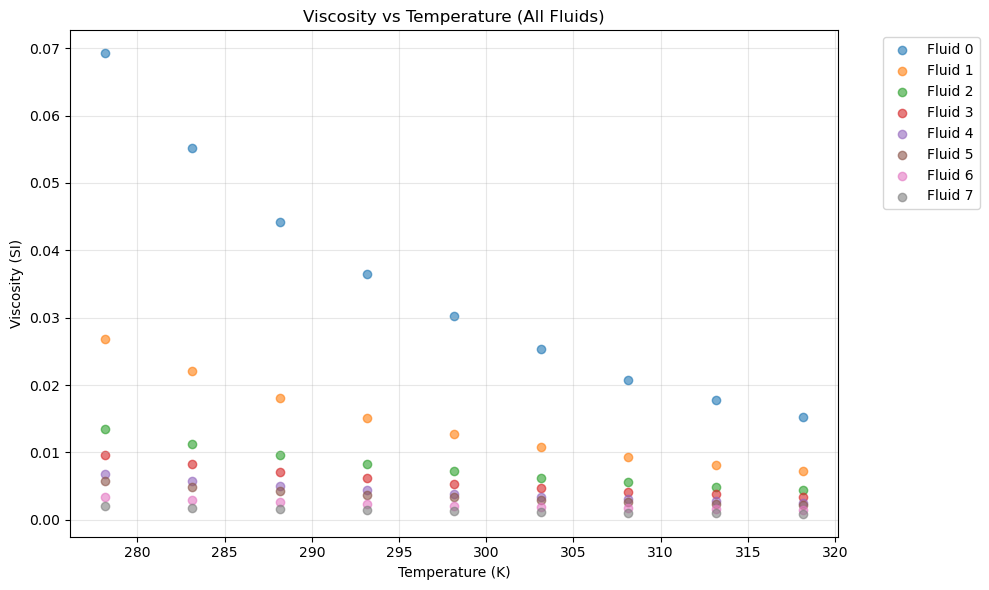

In [44]:

from fairfluids.core.lib import Properties, Parameters
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# Match enum-based column names from fluid_to_dataframe
viscosity_col = f"prop_{Properties.VISCOSITY.value}"
temp_col = f"param_{Parameters.TEMPERATURE.value}"

plotted_any = False
for i, fluid in enumerate(docs.fluid):
    df = fluid_to_dataframe(fluid)
    if viscosity_col in df.columns and temp_col in df.columns:
        ax.scatter(df[temp_col], df[viscosity_col], alpha=0.6, label=f"Fluid {i}")
        plotted_any = True

if plotted_any:
    ax.set_xlabel("Temperature (K)")
    ax.set_ylabel("Viscosity (SI)")
    ax.set_title("Viscosity vs Temperature (All Fluids)")
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
else:
    print("No matching viscosity/temperature columns found in any fluid.")
    print("Available columns in first fluid:", fluid_to_dataframe(docs.fluid[0]).columns.tolist())

plt.tight_layout()
plt.show()

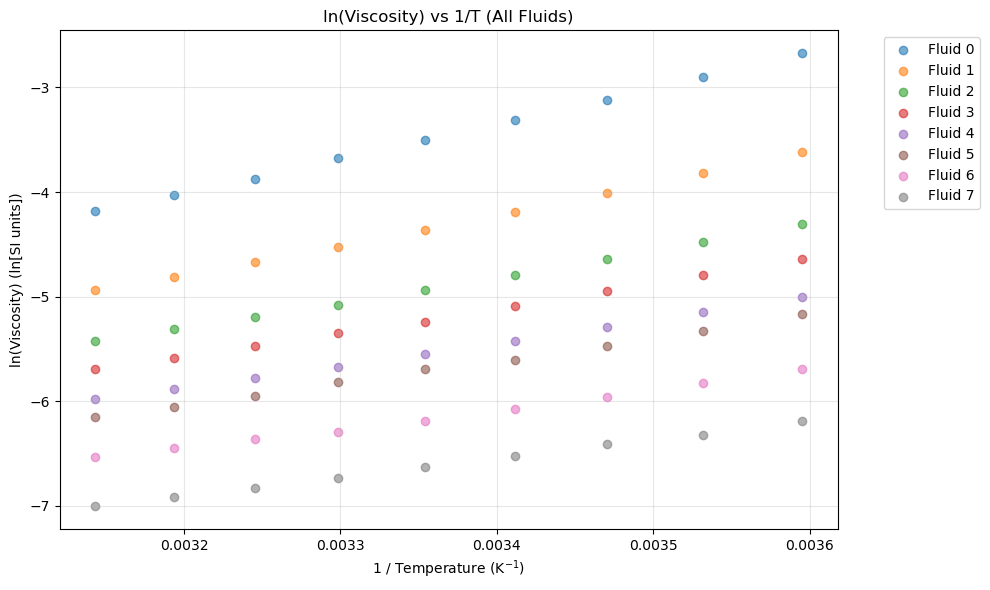

In [45]:

from fairfluids.core.lib import Properties, Parameters
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))

viscosity_col = f"prop_{Properties.VISCOSITY.value}"
temp_col = f"param_{Parameters.TEMPERATURE.value}"

plotted_any = False
R = 8.314462618  # J/(mol·K), universal gas constant, not strictly required for just 1/T
for i, fluid in enumerate(docs.fluid):
    df = fluid_to_dataframe(fluid)
    if viscosity_col in df.columns and temp_col in df.columns:
        temperature = df[temp_col]  # assume K
        viscosity = df[viscosity_col]
        # Mask physically meaningful values
        mask = (viscosity > 0) & (temperature > 0)
        if mask.any():
            x = 1.0 / temperature[mask]  # 1/T (K^-1)
            y = np.log(viscosity[mask])  # ln(viscosity)
            ax.scatter(x, y, alpha=0.6, label=f"Fluid {i}")
            plotted_any = True

if plotted_any:
    ax.set_xlabel("1 / Temperature (K$^{-1}$)")
    ax.set_ylabel("ln(Viscosity) (ln[SI units])")
    ax.set_title("ln(Viscosity) vs 1/T (All Fluids)")
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
else:
    print("No matching viscosity/temperature columns found in any fluid.")
    print("Available columns in first fluid:", fluid_to_dataframe(docs.fluid[0]).columns.tolist())

plt.tight_layout()
plt.show()

## 3) Quick validation of results


In [46]:
for i, d in enumerate(docs):
    print(f"Doc {i}: compounds={len(d.compound)} | fluids={len(d.fluid)}")
    if d.fluid and d.fluid[0].sample and d.fluid[0].sample.measurement:
        print("  first fluid measurements:", len(d.fluid[0].sample.measurement))

# Optional: inspect first measurement quickly
if docs and docs[0].fluid and docs[0].fluid[0].sample.measurement:
    m0 = docs[0].fluid[0].sample.measurement[0]
    print("\nFirst measurement summary")
    print("  method:", m0.method)
    print("  n property values:", len(m0.propertyValue))
    print("  n parameter values:", len(m0.parameterValue))

AttributeError: 'tuple' object has no attribute 'compound'

## 4) Save output JSON documents (optional)


In [48]:
output_dir = workflows_dir / "outputs_from_spreadsheet"
output_dir.mkdir(parents=True, exist_ok=True)

fio.data_from_spreadsheet(
    spreadsheet_path=str(spreadsheet_path),
    output_dir=str(output_dir),
    fetch_from_pubchem=True,
    units=units,
    uncertainty_units=uncertainty_units,
)

json_files = sorted(output_dir.glob("*.json"))
print(f"Saved {len(json_files)} JSON files to {output_dir}")
for p in json_files[:10]:
    print(" -", p.name)

Found 1 unique compound combinations

Fetching compound information from PubChem for 2 unique compounds...

Fetched data for 2 compounds

  Added compound: Cholinechloride -> Choline Chloride (CID: 6209)
  Added compound: Water -> Water (CID: 962)
Saved document to: /home/sga/Code/FAIRFluids/Workflows/outputs_from_spreadsheet/Cholinechloride_Water.json
Saved 4 JSON files to /home/sga/Code/FAIRFluids/Workflows/outputs_from_spreadsheet
 - Cholinechloride_Water.json
 - Glycerol_Water.json
 - glycerol_water.json
 - water_Cholinechloride_Glycerol.json


## Summary

You now have a working tutorial for the structured FAIRFluids spreadsheet workflow:

1. Generate template with `create_datasheet(...)`
2. Fill spreadsheet (`csv` or `xlsx`)
3. Import with `data_from_spreadsheet(...)`
4. Optionally enrich compounds via PubChem (`pubchemID i` preferred)
5. Validate documents/fluids/measurements and export JSON outputs